**Week 8 Project Task – DMNN**

**Focus: Convolutional Neural Networks (From Architecture to Interpretation)**

**Task 1 – Reconnect to the Data**

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

print("All imports successful ✅")

All imports successful ✅


In [8]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)
print("Single image shape:", x_train[0].shape)
print("Data type:", x_train.dtype)

x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)
Single image shape: (28, 28)
Data type: uint8


In [9]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

print("First 10 labels:", y_train[:10])
print("First 10 class names:", [class_names[i] for i in y_train[:10]])

First 10 labels: [9 0 0 3 0 2 7 2 5 5]
First 10 class names: ['Ankle boot', 'T-shirt/top', 'T-shirt/top', 'Dress', 'T-shirt/top', 'Pullover', 'Sneaker', 'Pullover', 'Sandal', 'Sandal']


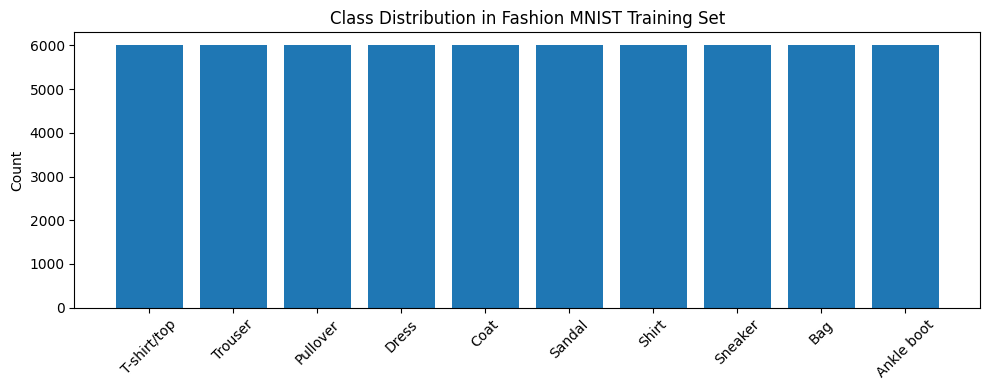

Class counts:
T-shirt/top: 6000
Trouser: 6000
Pullover: 6000
Dress: 6000
Coat: 6000
Sandal: 6000
Shirt: 6000
Sneaker: 6000
Bag: 6000
Ankle boot: 6000


In [10]:
class_counts = np.bincount(y_train)

plt.figure(figsize=(10, 4))
plt.bar(class_names, class_counts)
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.title("Class Distribution in Fashion MNIST Training Set")
plt.tight_layout()
plt.show()

print("Class counts:")
for name, count in zip(class_names, class_counts):
    print(f"{name}: {count}")

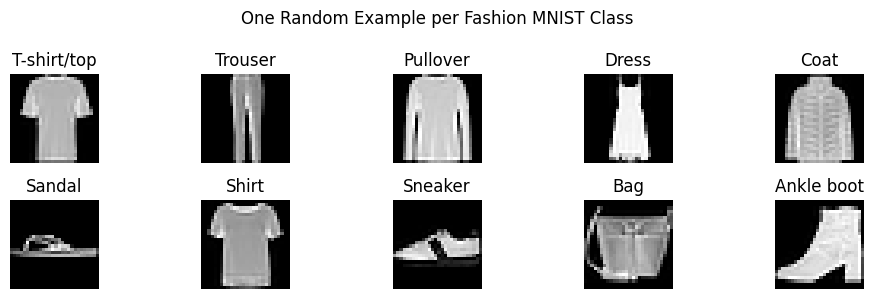

In [30]:
plt.figure(figsize=(10, 3))

for class_idx in range(10):
    indices = np.where(y_train == class_idx)[0]
    random_index = np.random.choice(indices)
    plt.subplot(2, 5, class_idx + 1)
    plt.imshow(x_train[random_index], cmap="gray")
    plt.title(class_names[class_idx])
    plt.axis("off")

plt.suptitle("One Random Example per Fashion MNIST Class")
plt.tight_layout()
plt.show()

**What one training example represents:**

each training example represents a single image of a class labelled fashion item. Each image consists of 28×28 pixel values, that the visual structure of the object formed by adjustment of light and dark pixels.

**Why spatial structure matters:**

Spatial structure matters because the meaning of the image depends on how nearby pixels are arranged. Features such as edges, outlines, soles, sleeves, and item shapes are formed by local pixel patterns rather than isolated pixel values. A CNN is suited to this perfectly because it learns local filters that move across the image and detect these spatial patterns.

**Why a fully connected network would be inefficient:**

A fully connected network would be inefficient because it would flatten the image into a 1D vector and ignore the natural 2D structure of the pixels. This cost in losing useful local relationships between neighbouring pixels and usually requires many more parameters. In contrast, CNNs use local connections and shared filters, making them more efficient and more suitable for image data.

**Task 2 – Build a Baseline CNN**

In [31]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("x_train new shape:", x_train.shape)
print("x_test new shape:", x_test.shape)

x_train new shape: (60000, 28, 28, 1)
x_test new shape: (10000, 28, 28, 1)


In [34]:
from sklearn.model_selection import train_test_split

x_train_main, x_val, y_train_main, y_val = train_test_split(
    x_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print("Training set shape:", x_train_main.shape)
print("Validation set shape:", x_val.shape)

Training set shape: (48000, 28, 28, 1)
Validation set shape: (12000, 28, 28, 1)


In [35]:
from tensorflow.keras import layers, models

baseline_model = models.Sequential([
    layers.Conv2D(16, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(10, activation="softmax")
])

/opt/anaconda3/envs/cnn_env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [37]:
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2704)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        27,050 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,632 (318.88 KB)

 Trainable params: 27,210 (106.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 54,422 (212.59 KB)

**What the convolution layer learns conceptually:**

The convolutional layer learns small local patterns in the image by applying filters across the input. In Fashion MNIST, these filters can detect features such as edges, curves, corners, and simple clothing outlines. The model is able to recognise similar patterns even when they appear in different positions because of appylying same filter across the whole images. 

**Role of pooling:**

The pooling layer reduces the spatial size of the feature maps while preserving the most important information. This helps reduce computation, lowers the number of effective activations passed forward, and makes the model more robust to small shifts in the position of image features.

**Trainable parameters:**

According to the model summary, the baseline CNN contains 27210 trainable parameters. Most of these parameters come from the final dense output layer after the feature maps have been flattened.

**Task 3 – Architectural Extension**

In [38]:
extended_model = models.Sequential([
    layers.Conv2D(16, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),
    layers.Flatten(),
    layers.Dense(10, activation="softmax")
])

extended_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [39]:
extended_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         8,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,810 (50.04 KB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
history_extended = extended_model.fit(
    x_train_main, y_train_main,
    epochs=10,
    batch_size=32,
    validation_data=(x_val, y_val),
    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8960 - loss: 0.2851 - val_accuracy: 0.8999 - val_loss: 0.2784
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8988 - loss: 0.2781 - val_accuracy: 0.9047 - val_loss: 0.2663
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8980 - loss: 0.2738 - val_accuracy: 0.9053 - val_loss: 0.2641
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9018 - loss: 0.2680 - val_accuracy: 0.9043 - val_loss: 0.2701
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9020 - loss: 0.2669 - val_accuracy: 0.9018 - val_loss: 0.2726
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9032 - loss: 0.2640 - val_accuracy: 0.9025 - val_loss: 0.2691
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9032 - loss: 0.2632 - val_accuracy: 0.9076 - val_loss: 0.2576
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9064 - loss: 0.2577 - 

**Architectural extension:**

The baseline CNN increased by adding a second convolutional layer, the number of filters in the second layer has been increased to 32, and a dropout layer with rate 0.3 was introduced. These changes make the model slightly deeper and increase its capacity to learn more complex visual features.

**Why this change may help:**

The additional convolutional layer allows the model to learn more detailed and hierarchical patterns. The first convolution layer can capture simple local features such as edges and outlines, while the second layer can combine these into more meaningful structures related to shape of clothes. Also, dropout can reduce reliance on any single activation and improve generalisation.

**One possible risk:**

A possible risk to this change is overfitting. Because the extended model has greater complexity and more trainable parameters than the baseline model. In order to remain stable a deeper model may require more careful training. 

**Task 4 – Training Behaviour Analysis**

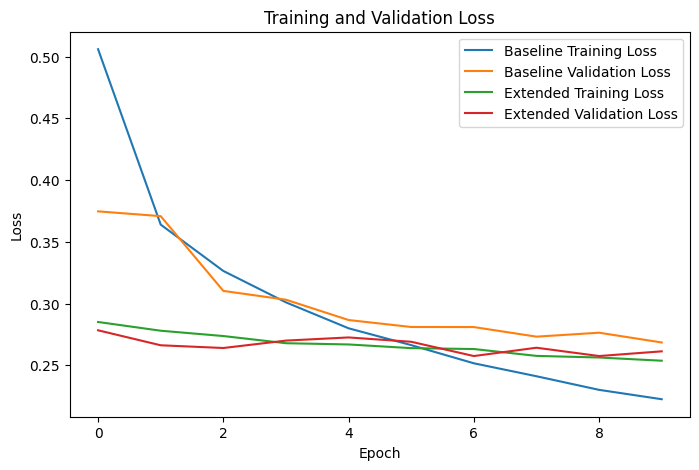

In [43]:
plt.figure(figsize=(8, 5))
plt.plot(history_baseline.history["loss"], label="Baseline Training Loss")
plt.plot(history_baseline.history["val_loss"], label="Baseline Validation Loss")
plt.plot(history_extended.history["loss"], label="Extended Training Loss")
plt.plot(history_extended.history["val_loss"], label="Extended Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

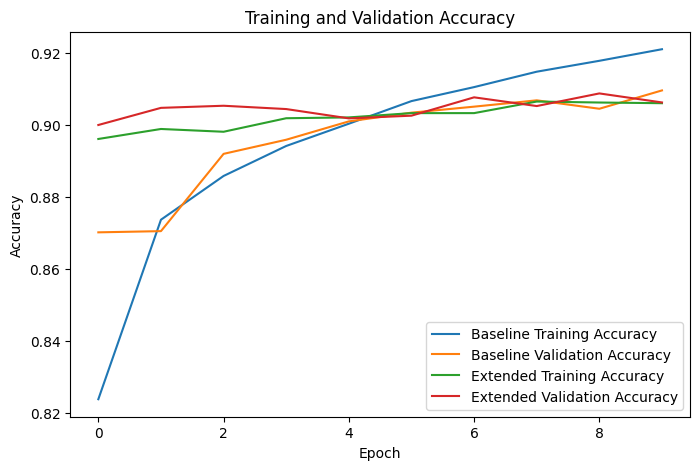

In [44]:
plt.figure(figsize=(8, 5))
plt.plot(history_baseline.history["accuracy"], label="Baseline Training Accuracy")
plt.plot(history_baseline.history["val_accuracy"], label="Baseline Validation Accuracy")
plt.plot(history_extended.history["accuracy"], label="Extended Training Accuracy")
plt.plot(history_extended.history["val_accuracy"], label="Extended Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

**Convergence behaviour:**

The training process for both models appears stable, as the loss decreases smoothly over epochs and the accuracy increases without large fluctuations. The baseline model shows slightly more consistent behaviour because of its simpler architecture. The extended model also remains stable, although it exhibits minor variations across epochs, which is expected given its higher complexity. Overall, both models demonstrate stable training behaviour without signs of instability or divergence.

**Signs of overfitting:**

There is no strong evidence of overfitting in either model. Training and validation accuracy remain close throughout the epochs, and validation loss does not increase. This indicates that both models generalise well to unseen data. However, the baseline model shows a slight divergence in later epochs where training accuracy continues to improve while validation performance stabilises, suggesting a very mild tendency toward overfitting.

**Stability of training:**

The training process for both models appears stable, as the loss decreases slightly over epochs and the accuracy increases without large fluctuations. The baseline model shows slightly more consistent behaviour due to its simpler architecture. The extended model also remains stable, although it exhibits minor variations across epochs, which is expected given its higher complexity. Overall, both models demonstrate stable training behaviour without signs of instability or divergence.

**Relation to architectural complexity:**

The extended model has higher complexity because it includes an additional convolution layer and more filters. This can improve feature learning, but it also increases the risk of fitting the training data too closely. The comparison between training and validation curves is therefore more informative than accuracy alone.


**Task 5 – Controlled Test-Set Evaluation**

In [45]:
test_loss_baseline, test_acc_baseline = baseline_model.evaluate(x_test, y_test, verbose=0)
test_loss_extended, test_acc_extended = extended_model.evaluate(x_test, y_test, verbose=0)

print("Baseline Test Accuracy:", test_acc_baseline)
print("Extended Test Accuracy:", test_acc_extended)

Baseline Test Accuracy: 0.9014000296592712
Extended Test Accuracy: 0.8991000056266785


**Test set evaluation:**

The baseline model achieved a test accuracy of approximately 90.14%, while the extended model achieved approximately 89.91%. The results are very similar, with the baseline model performing slightly better.

**conclusion**

The test set must not be used to guide model design or architectural decisions, as it is intended to provide an unbiased estimate of model performance on unseen data. Using the test set during development would lead to overfitting to the test data and an overly optimistic evaluation.

The test results are consistent with the validation trends observed during training. Both models achieved similar performance on the validation set, and this behaviour is reflected in the test results. Therefore, validation set provided a reliable estimate of generalisation performance.

The small difference in accuracy between the baseline and extended models should not be overinterpreted. Such differences may arise due to randomness in training rather than meaningful differences in model quality.

The fact that the simpler baseline model slightly outperforms the more complex extended model suggests that increasing architectural complexity does not necessarily lead to better performance. While the extended model has greater capacity to learn complex features, it may also introduce additional noise or mild overfitting, making the simpler model more effective for this dataset.
